## Financial Forecasting using neural networks 

In this notebook, I aim to predict the S&P 500 index price using data spanning four years (from 2022-01-01 to 2026-01-24). The S&P 500 was selected as the primary benchmark because it serves as a comprehensive barometer for the U.S. economy, tracking the performance of 500 leading publicly traded companies.

Furthermore, since financial sentiment on platforms like Reddit tends to mirror broad market trends rather than isolated equities, this index is a highly representative proxy for the global market's collective movement. By combining historical price action with public sentiment, the goal is to evaluate if social data provides a predictive edge in forecasting index trends.

### Import libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kurtosis, skew
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from datasets import load_dataset
import yfinance as yf
import arch
from math import sqrt
from sklearn.metrics import mean_squared_error,mean_absolute_error
from arch.unitroot import VarianceRatio
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint
from keras.models import Sequential
from keras.layers import LSTM,Conv1D,Conv2D,MaxPooling2D,MaxPooling1D,Flatten, Bidirectional
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
seed=42

In [6]:
# Set global seeds to ensure reproducible results across runs
import os
import random
seed = 42

def set_reproducibility(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(seed)

####  Download the dataframe using yfinance library

In [7]:
ticker = "SPY"
start = "2022-01-01"
end   = "2026-01-24"

# Download dataframe
df = yf.download(
    ticker,
    start=start,
    end=end,
    auto_adjust=False,
    progress=False,
    multi_level_index=False
)

In [8]:
# Cleanded dataset
df = df.dropna().copy()
df.index.name = "date" 

data_SPY = df[["Open", "High", "Low", "Close", "Volume", "Adj Close"]]

data_SPY.head()

,Open,High,Low,Close,Volume,Adj Close
date,,,,,,
2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875214
2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785
2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049774
2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633545
2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883575


### Price evolution of S&P 500

Text(0, 0.5, 'Adj. Close')

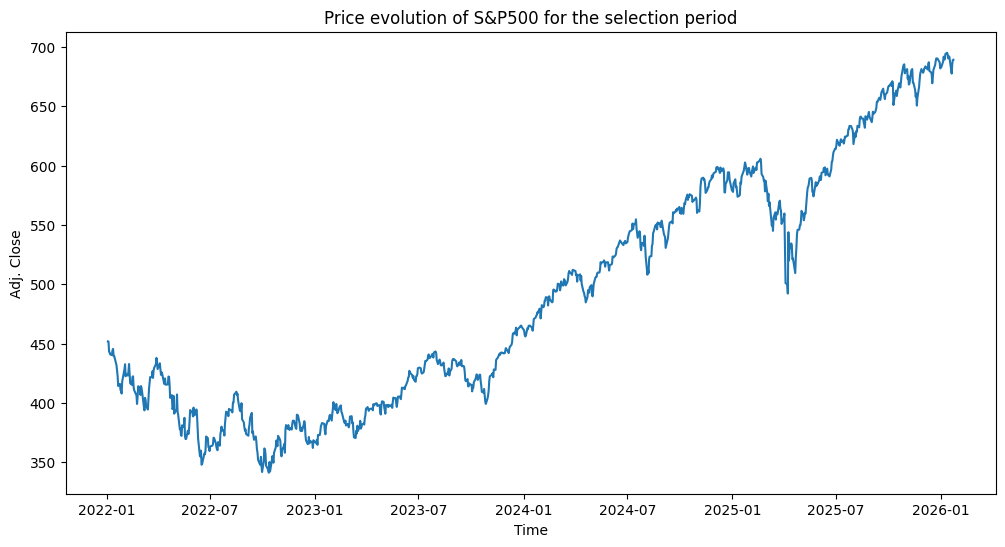

In [9]:
plt.figure(figsize=(12,6))
plt.plot(data_SPY.index, data_SPY['Adj Close'])
plt.title('Price evolution of S&P500 for the selection period')
plt.xlabel('Time')
plt.ylabel('Adj. Close')

### Log-Returns

In [10]:
log_returns = np.log(data_SPY / data_SPY.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
log_returns.head()

,Open,High,Low,Close,Volume,Adj Close
date,,,,,,
2022-01-04,0.006112,0.004448,0.003644,-0.000335,-0.020710,-0.000335
2022-01-05,-0.004308,-0.004176,-0.015469,-0.019389,0.384366,-0.019389
2022-01-06,-0.019619,-0.015093,-0.006105,-0.000940,-0.185274,-0.000940
2022-01-07,0.000128,-0.003447,-0.001677,-0.003961,-0.020322,-0.003961
2022-01-10,-0.011283,-0.007402,-0.017477,-0.001245,0.338198,-0.001245


Text(0.5, 1.0, 'Evolution of Log_returns')

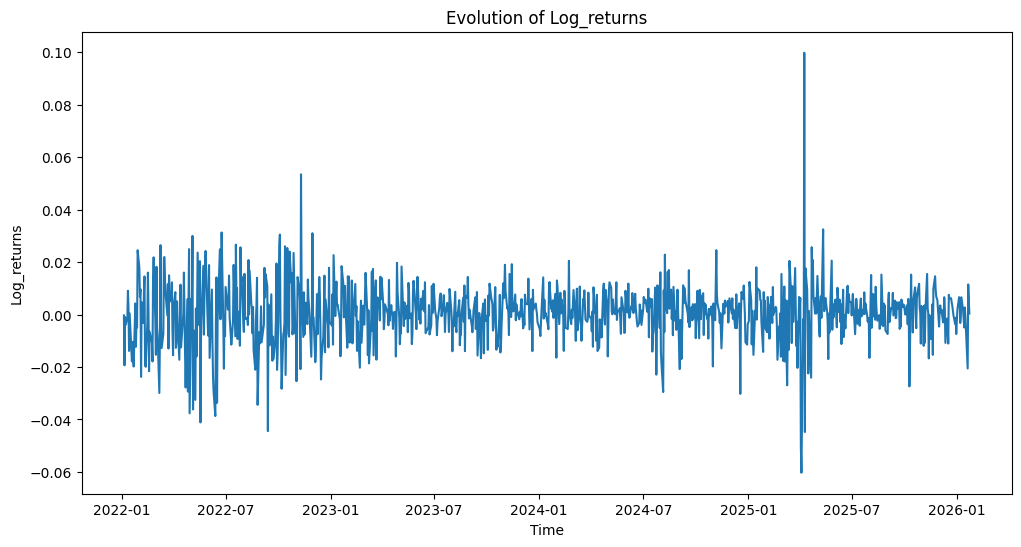

In [11]:
#Log-returns evolution plot
plt.figure(figsize=(12,6))
plt.plot(log_returns.index, log_returns['Close'])
plt.xlabel('Time')
plt.ylabel('Log_returns')
plt.title('Evolution of Log_returns')

Text(0.5, 1.0, 'Histogram of Log_returns')

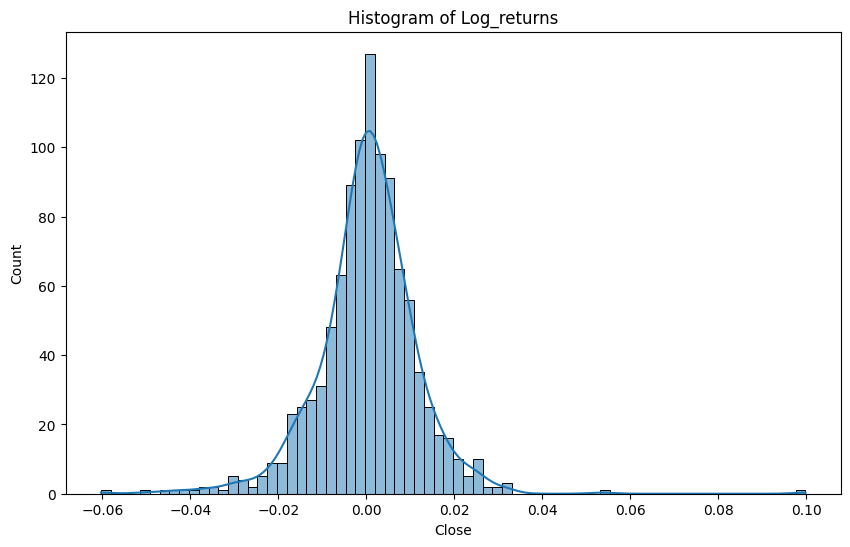

In [ ]:
#Histogram of Log_Returns
plt.figure(figsize=(10,6))
sns.histplot(data=log_returns, x='Close', kde=True)
plt.title('Histogram of Log_returns')

In [8]:
skewness = log_returns['Close'].skew()
kurt = log_returns['Close'].kurt()

skew_hurt = pd.DataFrame({
        'Metric': ['Skewness','Kurtosis'],
        'Value' : [skewness, kurt] 
})

skew_hurt


,Metric,Value
0,Skewness,0.185334
1,Kurtosis,8.077854


The log-returns show the presence of a positive shew of 0.18 indicating a distribution that leans slightly to the right.
The kurtosis of 8.07 confirms a highly leptokurtic distribution, signaling the presence of "fat tails", meaning that the market experiences extreme price swings far more often than a standard distribution.

### Efficient Market Hypothesis (EMH)

Text(0.5, 1.0, 'Autocorrelation of S&P 500 Log Returns')

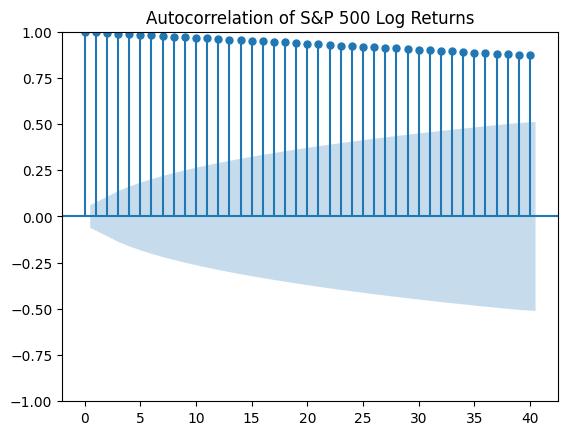

In [9]:
plot_acf(data_SPY['Close'], lags=40)
plt.title('Autocorrelation of S&P 500 Log Returns')

<Figure size 800x500 with 0 Axes>

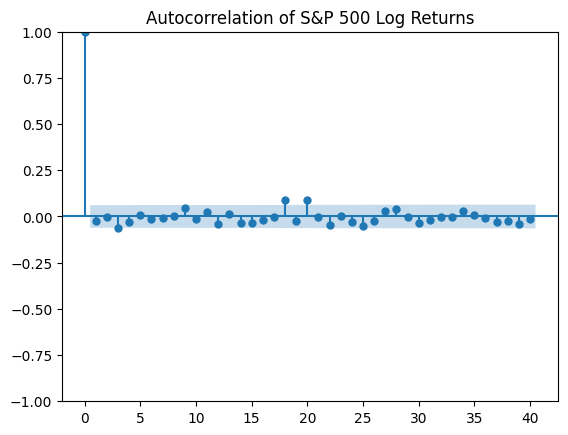

In [10]:
plt.figure(figsize=(8, 5))
plot_acf(log_returns['Close'], lags=40)
plt.title('Autocorrelation of S&P 500 Log Returns')
plt.show()

In [11]:
#L-jung Box test
#H0: The series of returns is white noise (randomly distributed).
#H1: The series of returns is not white noise (exhibits serial correlation).

res_returns = acorr_ljungbox(log_returns['Close'], lags=[10], return_df=True)
res_returns

,lb_stat,lb_pvalue
10,8.321316,0.597483


In [12]:
# Run test on squared returns (checks for volatility prediction)
res_volatility = acorr_ljungbox(log_returns['Close']**2, lags=[10], return_df=True)
res_volatility

,lb_stat,lb_pvalue
10,192.623092,5.560992e-36


This show that the series of volatitiliy is not white noise, showing the existance of "Volatility Clustering"

In [13]:
#Variance Ratio test
#H0: The series follows a random walk (The variance ratio is equal to 1).
#H1: The series does not follow a random walk (The variance ratio is significantly different from 1).
vr = VarianceRatio(log_returns['Close'], lags=10)

print(vr.summary())

     Variance-Ratio Test Results     
Test Statistic                 -4.465
P-value                         0.000
Lags                               10
-------------------------------------

Computed with overlapping blocks (de-biased)


The Random Walk Hypothesis is rejected (as the Variance Ratio is significantly different from 1), suggesting that over medium and long-term horizons, the series exhibits autocorrelation or other dynamics that cause it to deviate from a pure random walk. This indicates that price movements are systematically influenced by market volatility and external factors.
Because the market isn't perfectly efficient, it means there are patterns hidden in the noise. By moving beyond just looking at prices and including sentiment analysis (like financial news), we can try to capture the human irrationality that the EMH ignores.

### LSTM with sentiment analysis 

In [12]:
data_final_news = pd.read_csv('../datasets/Data_final_news_reddit.csv')
data_final_news.head()

,date,clean,transformer_sentiment_label,transformer_sentiment_score
0,2009-05-09,sp500 elliott wave update competiting interpre...,neutral,0
1,2009-06-04,the gold bull market and the fed it rode in on,neutral,0
2,2009-06-25,what inflation rates fall as fed sells 25b i...,negative,-1
3,2009-10-10,tmobile sidekick disaster microsoft and tmobil...,negative,-1
4,2010-05-10,correlation math signals bull market oil\r\nst...,positive,1


In [13]:
data_SPY_reset = data_SPY.reset_index()
data_SPY_reset.head()

,date,Open,High,Low,Close,Volume,Adj Close
0,2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875214
1,2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785
2,2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049774
3,2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633545
4,2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883575


In [14]:
data_SPY_reset['date'] = pd.to_datetime(data_SPY_reset['date'])
data_final_news['date'] = pd.to_datetime(data_final_news['date'])

In [15]:
final_dataset = pd.merge(data_SPY_reset,
                         data_final_news[['date', 'transformer_sentiment_score']],
                         on='date',
                         how='left')

In [16]:
final_dataset[['transformer_sentiment_score']] = final_dataset[['transformer_sentiment_score']].fillna(0)

In [17]:
final_dataset.head(10)

,date,Open,High,Low,Close,Volume,Adj Close,transformer_sentiment_score
0,2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875214,-1.0
1,2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785,0.0
2,2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049774,0.0
3,2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633545,0.0
4,2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883575,0.0
5,2022-01-10,462.700012,465.739990,456.600006,465.510010,119362000,440.334930,0.0
6,2022-01-11,465.230011,469.850006,462.049988,469.750000,74303100,444.345642,0.0
7,2022-01-12,471.589996,473.200012,468.940002,471.019989,67605400,445.546967,1.0
8,2022-01-13,472.190002,472.880005,463.440002,464.529999,91173100,439.407898,0.0
9,2022-01-14,461.190002,465.089996,459.899994,464.720001,95890900,439.587616,0.0


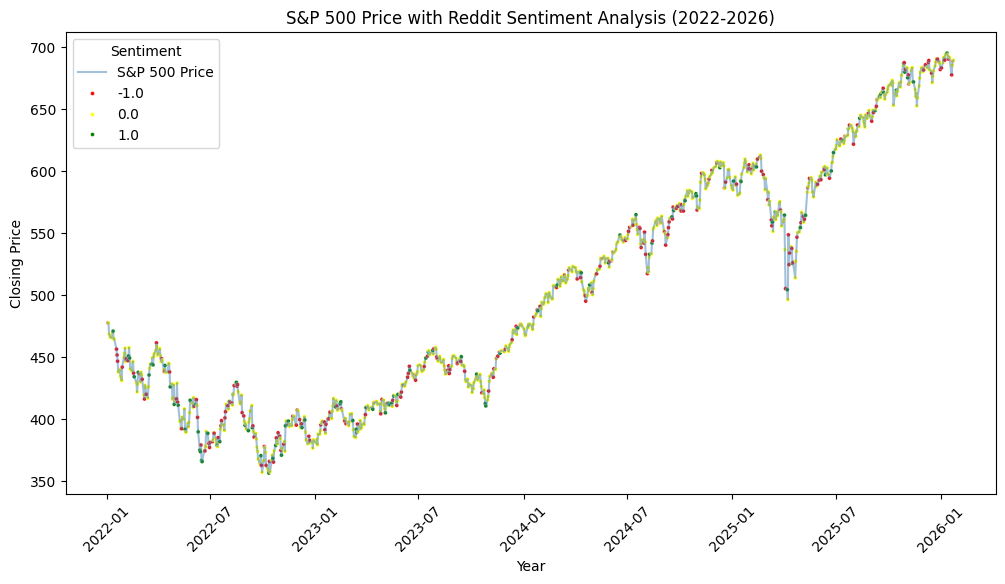

In [18]:
#Plot to showcase the sentiment scores in the price evolution of S&P500
palette_colors = {1.0: 'green', -1.0: 'red', 0.0: 'yellow'}

plt.figure(figsize=(12, 6))
sns.lineplot(data=final_dataset, x='date', y='Close', color='steelblue', alpha=0.5, label='S&P 500 Price')
sns.scatterplot(data=final_dataset, 
                x='date', 
                y='Close', 
                hue='transformer_sentiment_score', 
                palette=palette_colors,
                s=8)
plt.xticks(rotation=45)
plt.title('S&P 500 Price with Reddit Sentiment Analysis (2022-2026)')
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.legend(title='Sentiment', loc='upper left')

In [19]:
final_dataset['transformer_sentiment_score'].value_counts()

transformer_sentiment_score
 0.0    682
-1.0    227
 1.0    109
Name: count, dtype: int64

In [20]:
final_dataset.head()

,date,Open,High,Low,Close,Volume,Adj Close,transformer_sentiment_score
0,2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200,451.875214,-1.0
1,2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700,451.723785,0.0
2,2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900,443.049774,0.0
3,2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900,442.633545,0.0
4,2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600,440.883575,0.0


### LSTM model

In [22]:
train_dates = pd.to_datetime(final_dataset['date'])

#Variables for training
cols = [
    'Open',
    'High', 'Low',
    'Close',
    'Volume',
    'Adj Close',
    'transformer_sentiment_score'
        ]

#New dataframe with only training data
df_for_training = final_dataset[cols].astype(float)
df_for_training.index=final_dataset['date']
df_for_training

,Open,High,Low,Close,Volume,Adj Close,transformer_sentiment_score
date,,,,,,,
2022-01-03,476.299988,477.850006,473.850006,477.709991,72668200.0,451.875214,-1.0
2022-01-04,479.220001,479.980011,475.579987,477.549988,71178700.0,451.723785,0.0
2022-01-05,477.160004,477.980011,468.279999,468.380005,104538900.0,443.049774,0.0
2022-01-06,467.890015,470.820007,465.429993,467.940002,86858900.0,442.633545,0.0
2022-01-07,467.950012,469.200012,464.649994,466.089996,85111600.0,440.883575,0.0
...,...,...,...,...,...,...,...
2026-01-16,693.659973,694.250000,690.099976,691.659973,79289200.0,691.659973,0.0
2026-01-20,681.489990,684.770020,676.570007,677.580017,111623300.0,677.580017,-1.0
2026-01-21,679.650024,688.739990,678.130005,685.400024,127844500.0,685.400024,0.0


### Standardize the data

In [ ]:
# Split data into training and test sets before scaling to prevent data leakage
split_point = int(len(df_for_training) * 0.8)

df_train_raw = df_for_training.iloc[:split_point]
df_test_raw = df_for_training.iloc[split_point:]

In [ ]:
scaler = StandardScaler()
scaler.fit(df_train_raw) #fit only on training data

df_train_scaled = scaler.transform(df_train_raw)
df_test_scaled = scaler.transform(df_test_raw)

scaler_for_inference = StandardScaler()
scaler_for_inference.fit(df_train_raw[['Adj Close']])

,copy,True
,with_mean,True
,with_std,True


In [ ]:
def create_sequences(data, n_past, n_future):
    X = []
    Y = []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        Y.append(data[i + n_future - 1:i + n_future, [5]])
    return np.array(X), np.array(Y)

n_past = 5
n_future = 1

trainX, trainY = create_sequences(df_train_scaled, n_past, n_future)
testX, testY = create_sequences(df_test_scaled, n_past, n_future)

print(f'TrainX shape = {trainX.shape}') # (Samples, 5, 7)
print(f'TrainY shape = {testX.shape}') # (Samples, 1, 1)

TrainX shape = (809, 5, 7)
TrainY shape = (199, 5, 7)


In [30]:
#train test split

x_train_no_news = trainX[:,:,:-1]
y_train_no_news = trainY

x_train_news = trainX
y_train_news= trainY

In [31]:
#creating the test and validation sets

x_val_no_news, x_test_no_news, y_val_no_news, y_test_no_news = train_test_split(testX[:,:,:-1], testY, test_size=0.5, shuffle=False)

x_val_news, x_test_news, y_val_news, y_test_news = train_test_split(testX, testY, test_size=0.5, shuffle=False)

print(f'Train size: {x_train_no_news.shape}, Validation size: {x_val_no_news.shape}, Test size:  {x_test_no_news.shape}')

Train size: (809, 5, 6), Validation size: (99, 5, 6), Test size:  (100, 5, 6)


In [ ]:
#create the model
def build_model(input_shape):
    tf.random.set_seed(seed)
    model = Sequential()

    model.add(Bidirectional(LSTM(256, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(0.2))


    model.add(Bidirectional(LSTM(256, return_sequences=False))) 
    model.add(Dropout(0.2))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(trainY.shape[2]))

    model.compile(optimizer='adam', loss='mse')
    return model

In [33]:
# fit the model

lstm_model_no_news=build_model((x_train_no_news.shape[1],x_train_no_news.shape[2]))
lstm_model_news=build_model((x_train_news.shape[1],x_train_news.shape[2]))

history_without_news = lstm_model_no_news.fit(x_train_no_news, y_train_no_news, epochs=50, batch_size=32, validation_data=(x_val_no_news, y_val_no_news), verbose=1 )


history_news = lstm_model_news.fit(x_train_news, y_train_news, epochs=50, batch_size=32, validation_data=(x_val_news, y_val_news), verbose=1 )

c:\Users\mihai\anaconda3\envs\financial_nlp_env\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.2017 - val_loss: 0.0581
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0190 - val_loss: 0.0258
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0141 - val_loss: 0.0279
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0137 - val_loss: 0.0476
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0145 - val_loss: 0.0118
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0114 - val_loss: 0.0631
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0127 - val_loss: 0.0320
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0128 - val_loss: 0.0153
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0117 - val_loss: 0.0464
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0116 - val_loss: 0.0400
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0129 - val_loss: 0.0167
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.

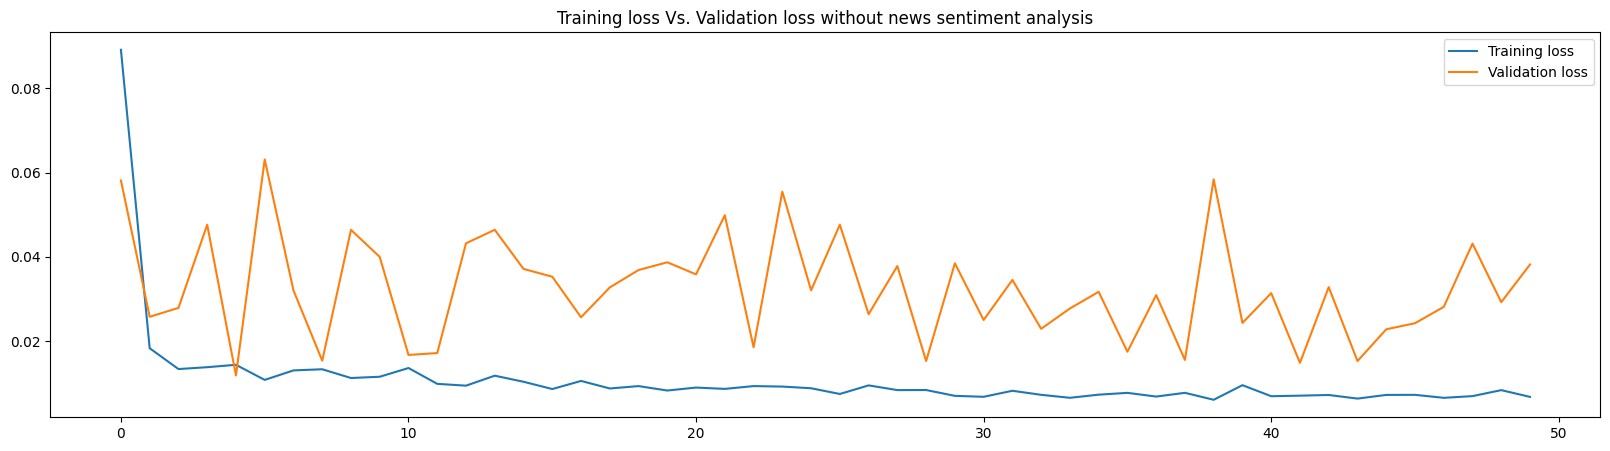

In [34]:
plt.figure(figsize=(20,5))
plt.plot(history_without_news.history['loss'], label='Training loss')
plt.plot(history_without_news.history['val_loss'], label='Validation loss')
plt.title('Training loss Vs. Validation loss without news sentiment analysis')
plt.legend()

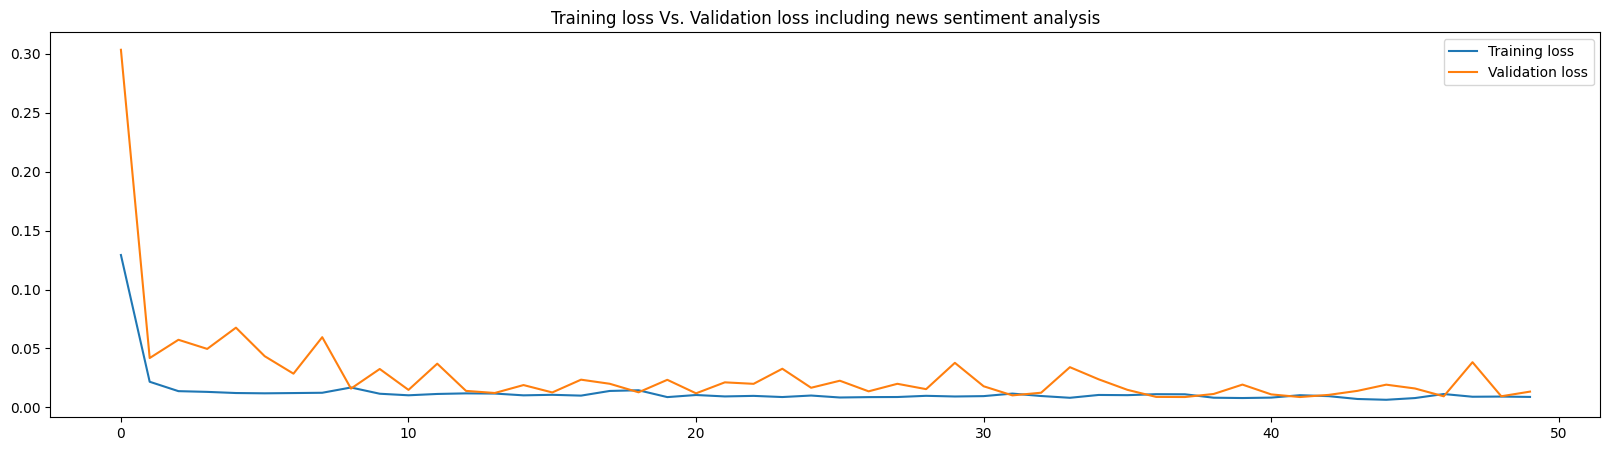

In [35]:
plt.figure(figsize=(20,5))
plt.plot(history_news.history['loss'], label='Training loss')
plt.plot(history_news.history['val_loss'], label='Validation loss')
plt.title('Training loss Vs. Validation loss including news sentiment analysis')
plt.legend()

In [ ]:

def plot_predictions_with_dates(type_data, news, dates, y_actual, y_pred):
    plt.figure(figsize=(15, 6))
    
    title_suffix = "With News Sentiment Analysis" if news else "Without News Sentiment Analysis"
    plt.title(f'LSTM {type_data} Prediction of Adj Close - {title_suffix}')
    
    sns.lineplot(x=dates, y=y_actual.flatten(), label='Actual Price', color='royalblue')
    sns.lineplot(x=dates, y=y_pred.flatten(), label='Predicted Price', color='orange')
    
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.show()
    
    mse = mean_squared_error(y_actual, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_actual, y_pred)
    
    print(f"Performance Metrics ({title_suffix})")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")

In [ ]:
#Get Predictions
pred_no_news = lstm_model_no_news.predict(x_train_no_news)
pred_news = lstm_model_news.predict(x_train_news)

pred_no_news = pred_no_news.reshape(pred_no_news.shape[0], -1)
pred_news = pred_news.reshape(pred_news.shape[0], -1)

y_train_pred_no_news = scaler_for_inference.inverse_transform(pred_no_news)
y_train_pred_news = scaler_for_inference.inverse_transform(pred_news)

y_actual_2d = y_train_no_news.reshape(y_train_no_news.shape[0], -1)
y_train_actual_lstm = scaler_for_inference.inverse_transform(y_actual_2d)

training_dates = df_for_training.index[n_past : n_past + len(y_train_actual_lstm)]

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


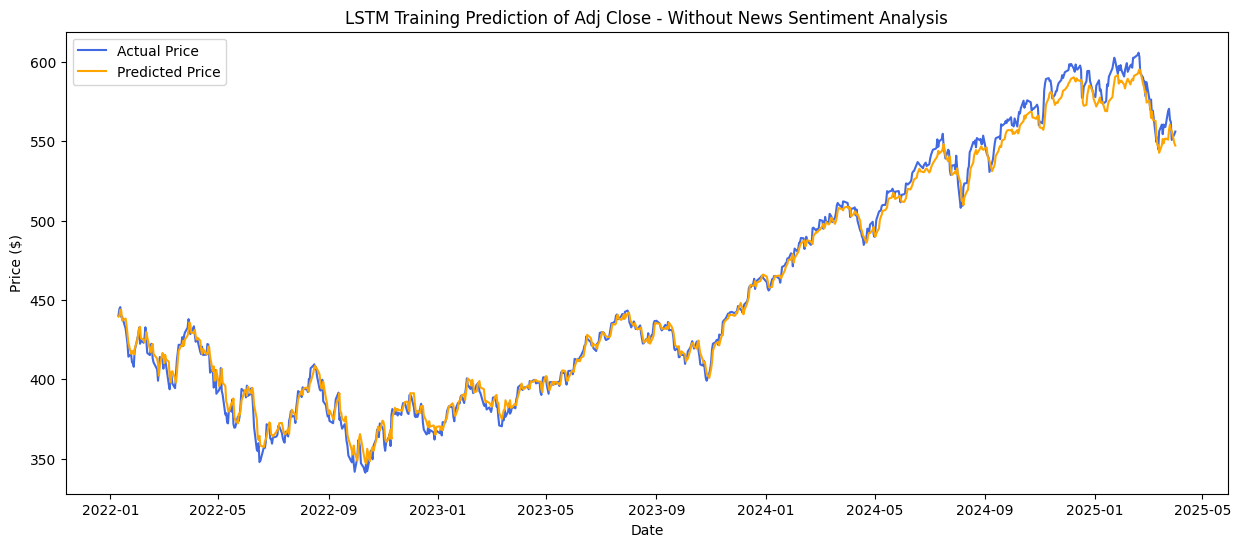

Performance Metrics (Without News Sentiment Analysis)
Mean Squared Error (MSE): 37.9118
Root Mean Squared Error (RMSE): 6.1573
Mean Absolute Error (MAE): 4.8443


In [38]:
plot_predictions_with_dates('Training',False,training_dates,y_train_actual_lstm,y_train_pred_no_news)

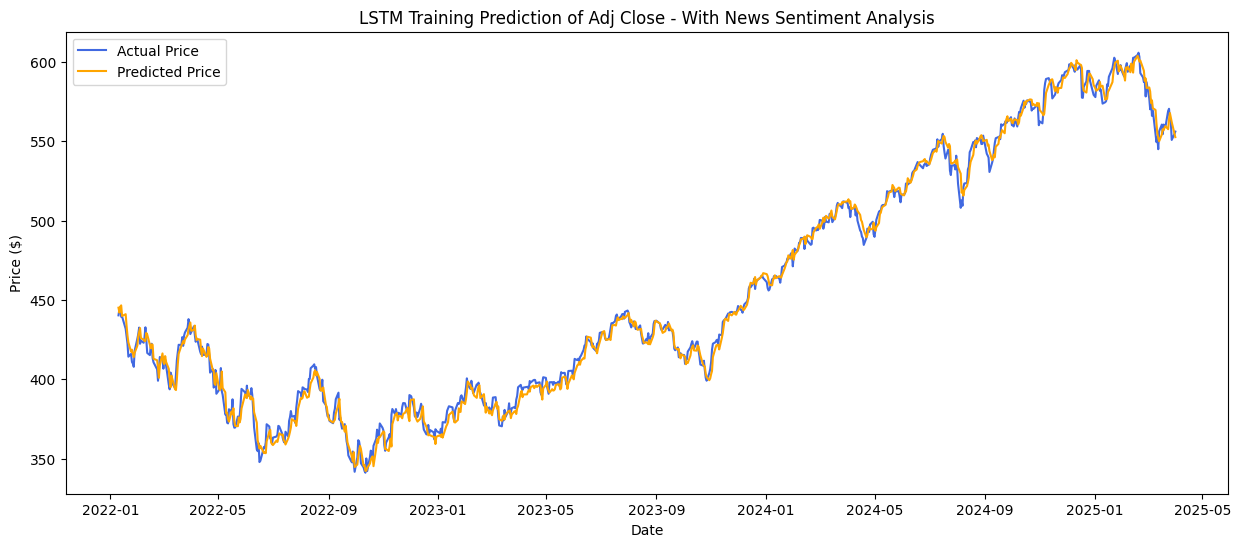

Performance Metrics (With News Sentiment Analysis)
Mean Squared Error (MSE): 27.7890
Root Mean Squared Error (RMSE): 5.2715
Mean Absolute Error (MAE): 4.0682


In [39]:
plot_predictions_with_dates('Training',True,training_dates,y_train_actual_lstm,y_train_pred_news)

In [ ]:
#Make prediction
testing_dates= df_for_training.index[-x_test_no_news.shape[0]:]

testing_no_news = lstm_model_no_news.predict(x_test_no_news)
testing_news = lstm_model_news.predict(x_test_news)

testing_no_news=testing_no_news.reshape(testing_no_news.shape[0], -1)
testing_news=testing_news.reshape(testing_news.shape[0], -1)

y_test_pred_no_news = scaler_for_inference.inverse_transform(testing_no_news)
y_test_pred_news = scaler_for_inference.inverse_transform(testing_news)

y_actual_2d = y_test_no_news.reshape(y_test_no_news.shape[0], -1)
y_test_actual_lstm = scaler_for_inference.inverse_transform(y_actual_2d)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


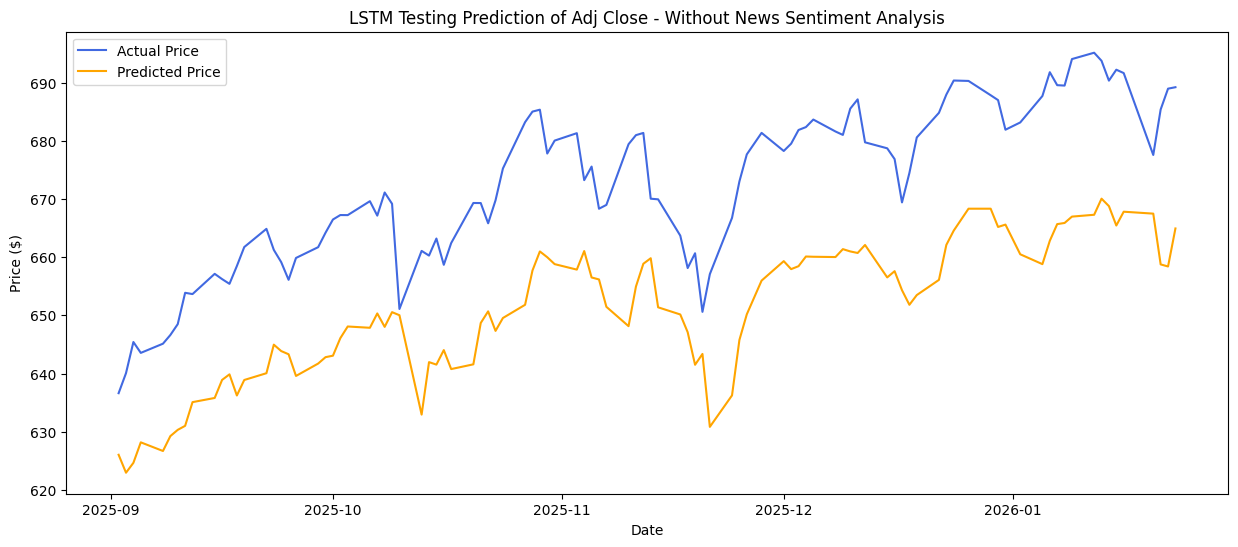

Performance Metrics (Without News Sentiment Analysis)
Mean Squared Error (MSE): 475.4152
Root Mean Squared Error (RMSE): 21.8040
Mean Absolute Error (MAE): 21.1046


In [41]:
plot_predictions_with_dates('Testing',False,testing_dates,y_test_actual_lstm,y_test_pred_no_news)

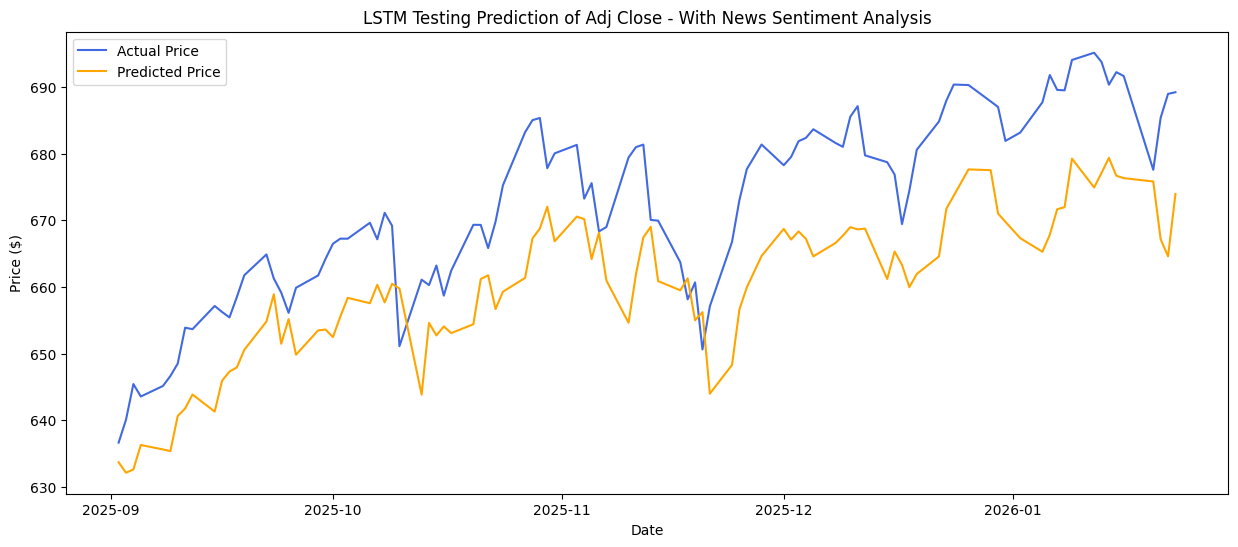

Performance Metrics (With News Sentiment Analysis)
Mean Squared Error (MSE): 179.1518
Root Mean Squared Error (RMSE): 13.3848
Mean Absolute Error (MAE): 12.2124


In [42]:
plot_predictions_with_dates('Testing',True,testing_dates,y_test_actual_lstm,y_test_pred_news)

Although the model shows high accuracy, it appears to be primarily predicting a simple lag-1 value (the previous day's price) rather than genuine trends. While the News dataset significantly reduced errors, suggesting that sentiment adds predictive value, the current reliance on raw closing prices limits the model's depth. To move beyond trivial sequence mapping, future iterations will focus on using stationary data, such as log-returns, to capture more meaningful market dynamics